# 06 - Analyse des classifications

## Objectif

Cette analyse étudie les classifications associées aux contenus.

Nous allons comparer les classifications des films et des séries, identifier les classifications les plus fréquentes et vérifier les anomalies présentes dans les données.


## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 2. Chargement des données

In [2]:
df = pd.read_csv("../data/processed/netflix_titles_clean.csv")

print(f"Nombre de contenus : {len(df)}")


Nombre de contenus : 8807


## 3. Répartition globale des classifications

In [3]:
rating_counts = df["rating"].value_counts()

rating_counts


rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

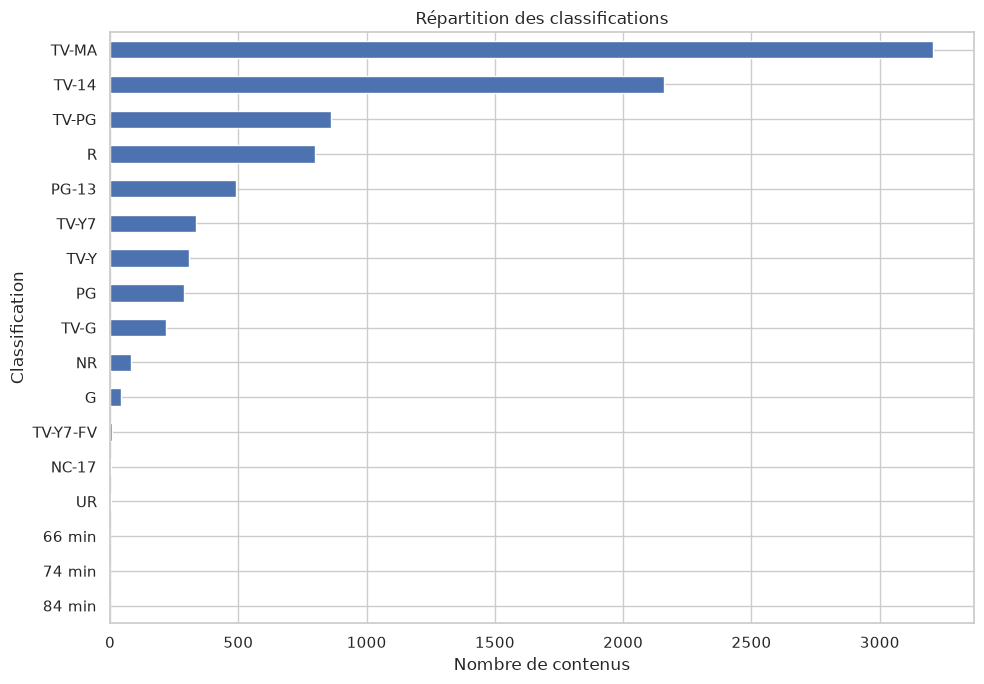

In [4]:
plt.figure(figsize=(10, 7))

rating_counts.sort_values().plot(kind="barh")

plt.title("Répartition des classifications")
plt.xlabel("Nombre de contenus")
plt.ylabel("Classification")
plt.tight_layout()
plt.show()


## 4. Pourcentage des classifications

In [5]:
rating_percentage = (
    df["rating"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

rating_percentage


rating
TV-MA       36.43
TV-14       24.54
TV-PG        9.80
R            9.08
PG-13        5.57
TV-Y7        3.79
TV-Y         3.49
PG           3.26
TV-G         2.50
NR           0.91
G            0.47
TV-Y7-FV     0.07
NC-17        0.03
UR           0.03
74 min       0.01
84 min       0.01
66 min       0.01
Name: proportion, dtype: float64

## 5. Classifications selon le type de contenu

In [6]:
rating_by_type = pd.crosstab(
    df["rating"],
    df["type"]
)

rating_by_type


type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


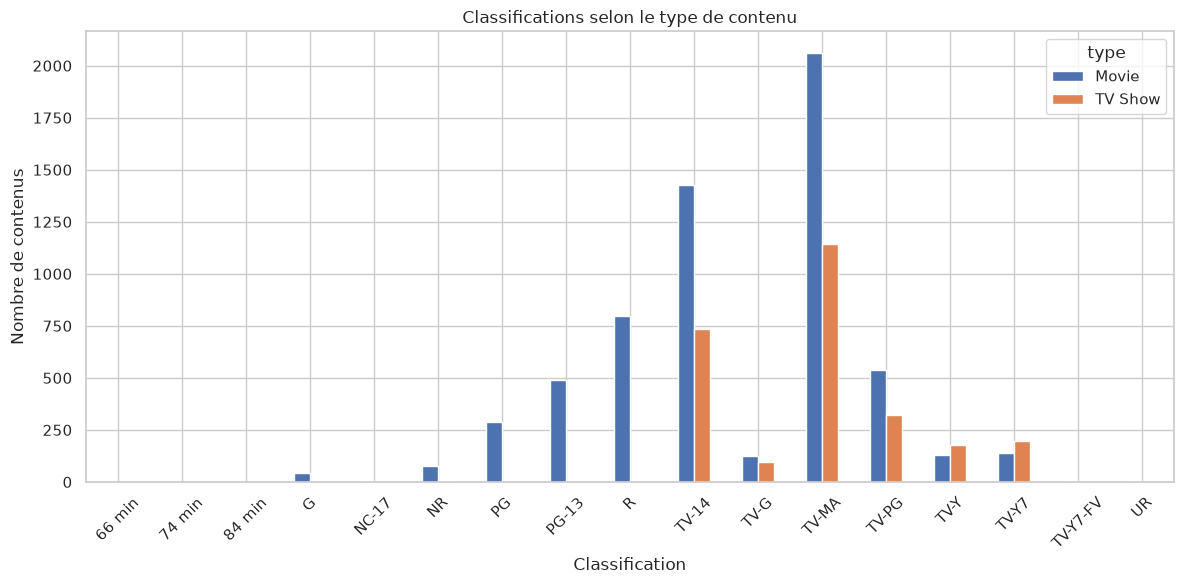

In [7]:
rating_by_type.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classifications selon le type de contenu")
plt.xlabel("Classification")
plt.ylabel("Nombre de contenus")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Classifications principales des films

In [8]:
movie_ratings = (
    df[df["type"] == "Movie"]["rating"]
    .value_counts()
)

movie_ratings


rating
TV-MA       2062
TV-14       1427
R            797
TV-PG        540
PG-13        490
PG           287
TV-Y7        139
TV-Y         131
TV-G         126
NR            75
G             41
TV-Y7-FV       5
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

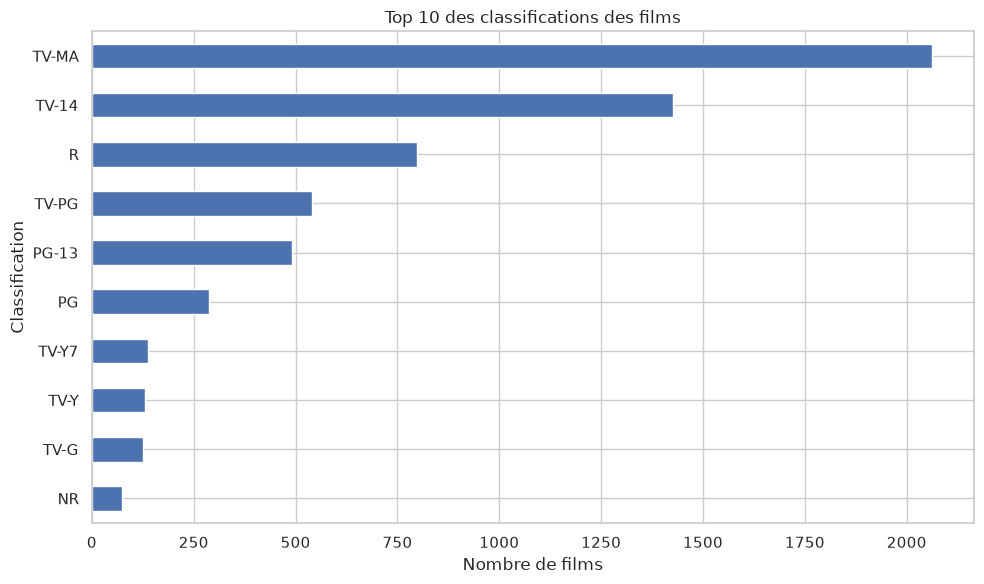

In [9]:
plt.figure(figsize=(10, 6))

movie_ratings.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 des classifications des films")
plt.xlabel("Nombre de films")
plt.ylabel("Classification")
plt.tight_layout()
plt.show()


## 7. Classifications principales des séries

In [10]:
show_ratings = (
    df[df["type"] == "TV Show"]["rating"]
    .value_counts()
)

show_ratings


rating
TV-MA       1145
TV-14        733
TV-PG        323
TV-Y7        195
TV-Y         176
TV-G          94
NR             5
R              2
TV-Y7-FV       1
Name: count, dtype: int64

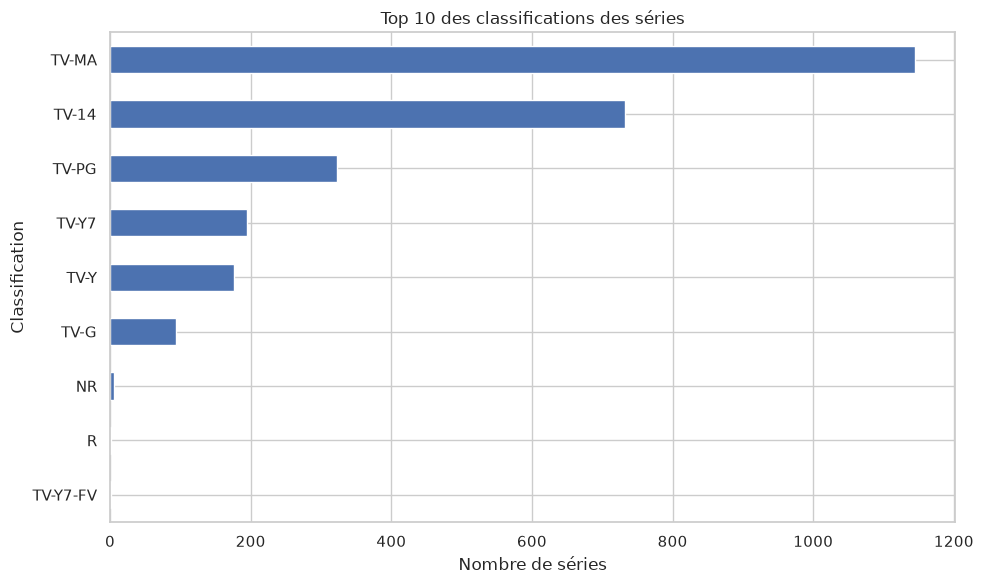

In [11]:
plt.figure(figsize=(10, 6))

show_ratings.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 des classifications des séries")
plt.xlabel("Nombre de séries")
plt.ylabel("Classification")
plt.tight_layout()
plt.show()


## 8. Détection des classifications anormales

In [12]:
anomalous_ratings = df[
    df["rating"].astype(str).str.match(r"^\d+ min$", na=False)
]

anomalous_ratings[
    ["show_id", "title", "type", "rating", "duration"]
]


,show_id,title,type,rating,duration
5541,s5542,Louis C.K. 2017,Movie,74 min,NaN
5794,s5795,Louis C.K.: Hilarious,Movie,84 min,NaN
5813,s5814,Louis C.K.: Live at the Comedy Store,Movie,66 min,NaN


### Observation

Certaines valeurs présentes dans `rating` correspondent à des durées exprimées en minutes (`66 min`, `74 min`, `84 min`).

Ces valeurs sont incohérentes pour une classification et indiquent une anomalie dans le dataset source.

Elles doivent être prises en compte avant toute analyse définitive des classifications.


## 9. Classifications les plus représentées

In [13]:
top_ratings = rating_counts.head(10)

top_ratings


rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

## 10. Classification dominante par type

In [14]:
dominant_rating = (
    df.groupby("type")["rating"]
    .agg(lambda x: x.value_counts().index[0])
)

dominant_rating


type
Movie      TV-MA
TV Show    TV-MA
Name: rating, dtype: str

## 11. Conclusion

Les classifications permettent d'observer des différences importantes entre les films et les séries.

Les classifications destinées aux programmes télévisés sont particulièrement présentes dans le catalogue, tandis que les films utilisent également des classifications cinématographiques comme `R`, `PG-13` ou `PG`.

L'analyse met également en évidence plusieurs anomalies de données qui devront être corrigées ou documentées avant une interprétation définitive.
